In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
df1 = pd.read_csv('flower_dataset.csv')

In [2]:
df1

,species,size,fragrance,height_cm
0,rose,medium,mild,48.55
1,shoeblack plant,medium,mild,147.07
2,shoeblack plant,medium,none,102.93
3,hibiscus,large,none,184.00
4,shoeblack plant,large,mild,83.07
...,...,...,...,...
9995,hibiscus,large,none,109.52
9996,shoeblack plant,medium,mild,145.23
9997,hibiscus,large,none,126.69
9998,shoeblack plant,large,none,77.62


In [3]:
df1.shape

(10000, 4)

In [4]:
df1.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   species    10000 non-null  str    
 1   size       10000 non-null  str    
 2   fragrance  10000 non-null  str    
 3   height_cm  10000 non-null  float64
dtypes: float64(1), str(3)
memory usage: 312.6 KB


In [5]:
df1.describe().round(2)

,height_cm
count,10000.00
mean,104.87
std,43.64
min,30.09
25%,69.31
50%,100.51
75%,137.02
max,199.97


In [6]:
df1["species"].unique()

<StringArray>
['rose', 'shoeblack plant', 'hibiscus']
Length: 3, dtype: str

In [7]:
df1["species"].value_counts()

species
rose               3345
shoeblack plant    3337
hibiscus           3318
Name: count, dtype: int64

In [8]:
df1["size"].unique()

<StringArray>
['medium', 'large', 'small']
Length: 3, dtype: str

In [9]:
df1["size"].value_counts()

size
large     4975
medium    3337
small     1688
Name: count, dtype: int64

In [10]:
df1["fragrance"].unique()

<StringArray>
['mild', 'none', 'strong']
Length: 3, dtype: str

In [11]:
df1["fragrance"].value_counts()

fragrance
none      5003
mild      3327
strong    1670
Name: count, dtype: int64

El dataset tiene 1000 filas y 4 columnas
La columna height_cm es de tipo float64, mientras que las otras tres son de tipo str

La columna species tiene tres valores unicos: rose, shoeblack plant, hibiscus, la mayoria de valores estan en rose
La columna size tiene tres valores unicos: medium, large, small, la mayoria de valores estan en large
La columna fragance tiene tres valores unicos: mild, none, strong, la mayoria de valores estan en none
En la columna height_cm la mayoria de los valores estan sesgados a la baja

Tipo de variables:
Numerica continua: height_cm
Categorica nominal: species
Categorica ordinal: size, fragance

<Axes: xlabel='size', ylabel='height_cm'>

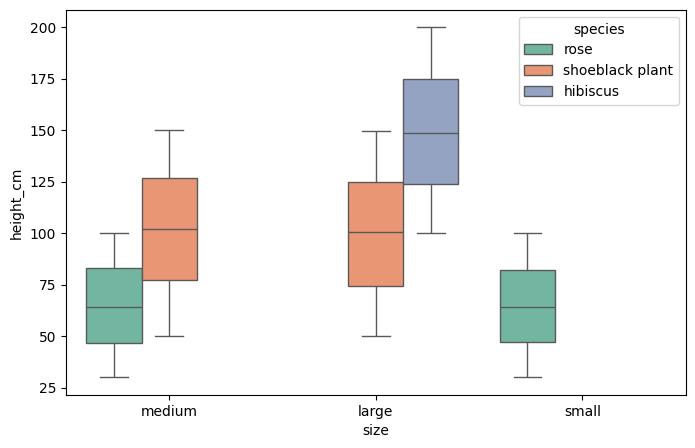

In [12]:
fig, ax = plt.subplots(figsize=(8, 5))

sns.boxplot(
    data=df1,
    y='height_cm',
    x='size',
    hue='species',
    palette='Set2',
    ax=ax
)

# Escalado

In [13]:
# --------------------------------------------------------
# BLOQUE 1 - IMPORTACIONES Y PREPROCESAMIENTO DE LOS DATOS
# --------------------------------------------------------


# 0. Importar las librerías necesarias
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

# 1. Cargar el conjunto de datos Iris
iris = df1.drop("species", axis=1)
le = LabelEncoder()
iris["size"] = le.fit_transform(iris["size"])
iris["fragrance"] = le.fit_transform(iris["fragrance"])
#iris_copia = pd.get_dummies(iris, columns=["species"])
X = iris  # Las características- IMPRESCINDIBLE !!


# Escalar el conjunto de datos
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

# Matriz de covarianza

In [14]:
X_scaled_copia = pd.DataFrame(X_scaled, columns=X_scaled.columns)
n = X_scaled_copia.shape[0]
cov_matrix = (X_scaled_copia.T @ X_scaled_copia) / (n - 1)

print("Matriz de covarianza:")
print(cov_matrix.round(3))

Matriz de covarianza:
            size  fragrance  height_cm
size       1.000      0.047     -0.639
fragrance  0.047      1.000      0.025
height_cm -0.639      0.025      1.000


# Api sklearn

In [15]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled_copia)

print(f"Forma original: {X.shape}")
print(f"Forma reducida: {X_pca.shape}")
print(f"Varianza explicada por componente: {pca.explained_variance_ratio_.round(3)}")
print(f"Varianza acumulada total: {pca.explained_variance_ratio_.sum():.3f}")

Forma original: (10000, 3)
Forma reducida: (10000, 2)
Varianza explicada por componente: [0.546 0.335]
Varianza acumulada total: 0.881


In [ ]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print(f"Forma original: {X.shape}")
print(f"Forma reducida: {X_pca.shape}")
print(f"Varianza explicada por componente: {pca.explained_variance_ratio_.round(3)}")
print(f"Varianza acumulada total: {pca.explained_variance_ratio_.sum():.3f}")

Forma original: (10000, 3)
Forma reducida: (10000, 3)
Varianza explicada por componente: [0.546 0.335 0.119]
Varianza acumulada total: 1.000


# KMeans

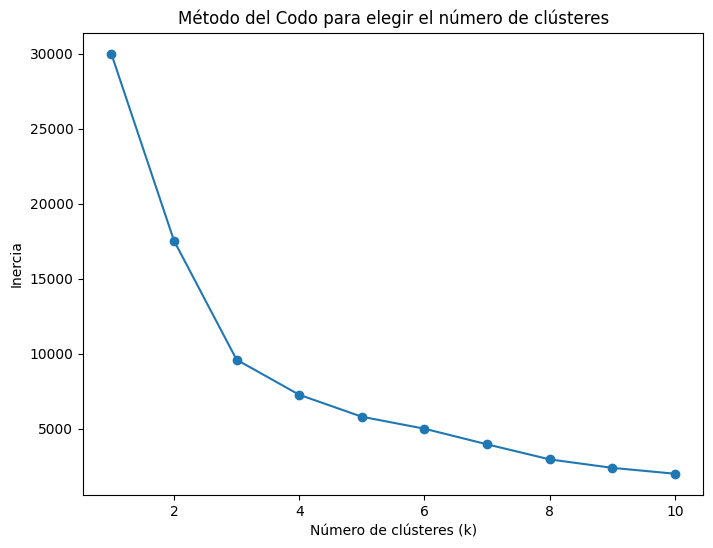

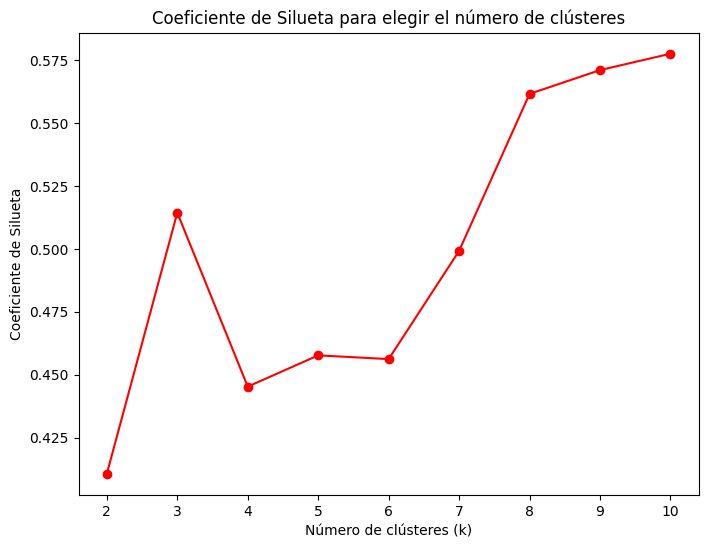

Silhouette Score para el modelo con 3 clústeres: 0.5143928204888806


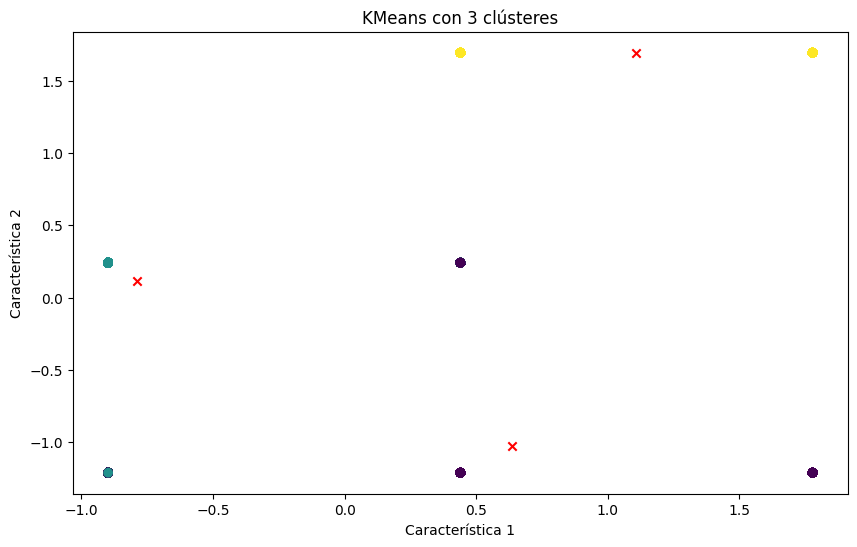

Número óptimo de clústeres según el Método del Codo y el Coeficiente de Silueta: 3
Centroides de los clústeres:
[[ 0.63464108 -1.02602354 -0.64810944]
 [-0.78946748  0.11448498  0.73630585]
 [ 1.10672077  1.69630443 -0.92046045]]


In [34]:
# -------------------------------------------------------------------------

# ---------------------------------------
# BLOQUE 2 - AJUSTE INICIAL DE PARÁMETROS
# ---------------------------------------

# 3. Método del Codo: Determinar el número óptimo de clústeres
inertia = []  # Guardaremos la inercia para diferentes valores de k (número de clústeres)
for k in range(1, 11):  # Probar para k = 1 hasta k = 10
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Graficar la inercia para cada k (Método del Codo)
plt.figure(figsize=(8, 6))
plt.plot(range(1, 11), inertia, marker='o')
plt.title('Método del Codo para elegir el número de clústeres')
plt.xlabel('Número de clústeres (k)')
plt.ylabel('Inercia')
plt.show()

# 4. Coeficiente de Silueta: Evaluar la calidad de los clústeres para diferentes valores de k
sil_scores = []  # Guardamos los coeficientes de silueta para cada k
for k in range(2, 11):  # El coeficiente de silueta solo es válido para k >= 2
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    sil_score = silhouette_score(X_scaled, kmeans.labels_)  # Calculamos el coeficiente de silueta
    sil_scores.append(sil_score)

# Graficar el coeficiente de silueta para cada k
plt.figure(figsize=(8, 6))
plt.plot(range(2, 11), sil_scores, marker='o', color='red')
plt.title('Coeficiente de Silueta para elegir el número de clústeres')
plt.xlabel('Número de clústeres (k)')
plt.ylabel('Coeficiente de Silueta')
plt.show()

# A partir de la gráfica, elegimos el número óptimo de clústeres (suponemos k=3)
optimal_k = 3

# -------------------------------------------------------------------------

# ---------------------------------------------------------------------
# BLOQUE 3 - CREAMOS Y ENTRENAMOS EL MODELO CON EL Nº DE CLÚSTER ÓPTIMO
# ---------------------------------------------------------------------

# 5. Aplicar KMeans con el número óptimo de clústeres
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
kmeans.fit(X_scaled)


# -------------------------------------------------------------------------

# --------------------------------------------------
# BLOQUE 4 - EVALUAMOS Y VISUALIZAMOS LOS RESULTADOS
# --------------------------------------------------
# 6. Evaluación del modelo usando Silhouette Score con el número óptimo de clústeres
sil_score_optimal = silhouette_score(X_scaled, kmeans.labels_)
print(f"Silhouette Score para el modelo con {optimal_k} clústeres: {sil_score_optimal}")


# 7. Visualizar los resultados de KMeans
plt.figure(figsize=(10, 6))
plt.scatter(X_scaled["size"], X_scaled["fragrance"], c=kmeans.labels_, cmap='viridis')  # Graficamos los puntos de datos coloreados por su clúster
centroids = kmeans.cluster_centers_  # Los centroides de los clústeres
plt.scatter(centroids[:, 0], centroids[:, 1], c='red', marker='x')  # Graficamos los centroides en rojo
plt.title(f'KMeans con {optimal_k} clústeres')
plt.xlabel('Característica 1')
plt.ylabel('Característica 2')
plt.show()

# 8. Resultados finales
print(f'Número óptimo de clústeres según el Método del Codo y el Coeficiente de Silueta: {optimal_k}')
print('Centroides de los clústeres:')
print(kmeans.cluster_centers_)
